# Projeto M1 – Operações Pontuais e Filtragem Espacial

## Fluxo do Processamento

1. Seleção das imagens: escolher três radiografias de uma mesma região anatômica do conjunto
MURA e justificar a seleção.
2. Caracterização inicial: apresentar as imagens originais e identificar seus principais problemas
de qualidade.
3. Inserção de ruído: adicionar ruído controlado às imagens e registrar os parâmetros utilizados.
4. Operação pontual: aplicar uma técnica de transformação de intensidade escolhida pelo grupo.
5. Suavização: reduzir o ruído utilizando uma técnica de filtragem espacial.
6. Aguçamento: realçar detalhes ou estruturas utilizando uma técnica espacial adequada.
7. Segunda configuração: modificar uma técnica, parâmetro ou ordem do pipeline e repetir o
processamento.
8. Análise por métricas: selecionar duas métricas dentre as apresentadas em aula e utilizá-las
para comparar as imagens original, degradada e processadas. A escolha das métricas deverá
ser justificada.
9. Discussão: identificar qual configuração apresentou o melhor resultado para cada imagem e
discutir situações em que uma técnica apresentou comportamento inadequado

### Importações gerais

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import measure
from google.colab.patches import cv2_imshow

### Inserção de ruído

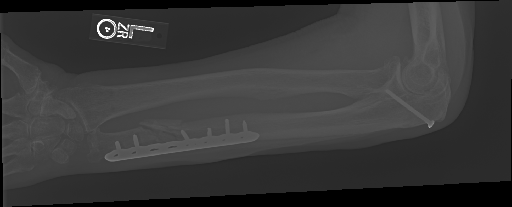

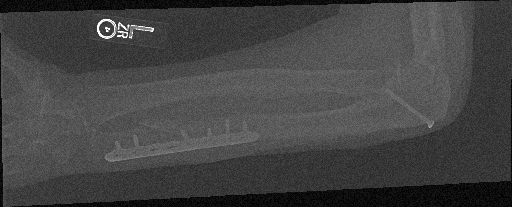

In [ ]:
img = cv2.imread('image1.png',0)

noise = np.zeros(img.shape, np.uint8)
cv2.randu(noise, 0, 25)

noisy_img = cv2.add(img, noise)

cv2_imshow(img)
cv2_imshow(noisy_img)

### Operação pontual: transformação de intensidade

Equalização de histograma

In [ ]:
def histogramaNormalizado(im):
  histogram = np.zeros(256)

  for i in range(im.shape[0]):
    for j in range(im.shape[1]):
      histogram[im[i, j]] += 1

  return histogram/(im.shape[0]*im.shape[1])

def histogramaAcumulado(histogram):
  acumulados = np.zeros(256)
  soma = 0

  for k in range(256):
    soma += histogram[k]
    acumulados[k] = soma

  return acumulados

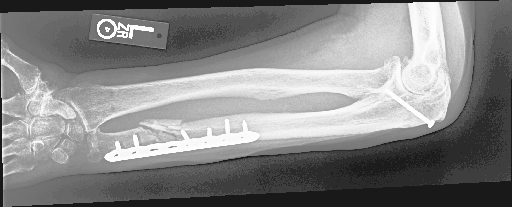

In [ ]:
def histEqualization(im):

  # histograma

  histogram = histogramaNormalizado(im)

  # histograma equalizado e imagem resultante

  sum = 0

  acumulados = histogramaAcumulado(histogram)

  for i in range(im.shape[0]):
    for j in range(im.shape[1]):
      im[i,j] = round(acumulados[im[i,j]]*255)

  return im

img_equalizada = histEqualization(img)

cv2_imshow(img_equalizada)